# Pretrain → Finetune@c → Forget, with AdamW everywhere

Minimal notebook: train with AdamW, sweep finetune concentrations, then forget with AdamW (c=0). No preconditioner decomposition, no shadow EMAs. We just observe the *actual* $\Delta\theta$ the optimizer takes each step and compute the 8b-style Taylor decomposition of $\Delta L_{\mathrm{ft}}$:

$$\Delta L_{\mathrm{ft}} \;\approx\; \underbrace{g_{\mathrm{ft}}(\theta_t)\cdot\Delta\theta}_{T_{\mathrm{first}}} \;+\; \underbrace{\tfrac{1}{2}\,\Delta\theta^\top H_{\mathrm{ft}}(\theta_t)\,\Delta\theta}_{T_{\mathrm{second}}}$$

- Start-of-interval convention: $g_{\mathrm{ft}}$ and $H_{\mathrm{ft}}$ evaluated at $\theta_t$ (before the step), so the quadratic gets a **+** sign.
- One HVP per step, at $\theta_t$ (we briefly restore params to $\theta_t$, compute the HVP, then put $\theta_{t+1}$ back).
- Black is actual $L_{\mathrm{ft}}(\theta_{t+1}) - L_{\mathrm{ft}}(\theta_t)$ measured on `eval_burst`; blue is the Taylor prediction `T_first + T_second`. Gap between them is pure 3rd-order Taylor truncation.

In [1]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from simple import make_data, pretrain, finetune, report
from simple.model import load_model
from simple.adam_forget_taylor import adam_forget_with_taylor

%matplotlib inline

OUT = "data/adam_forget"
SEED = 1
BATCH_SIZE = 512

data = make_data(depth=3, burst_pos=3, n_a=4, n_burst_fns=4, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")

Vocab: 40, Context: 37, Prompt: 12


## 1. Pretrain

Pretrain: 0it [00:00, ?it/s]


Converged at step 575 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5856


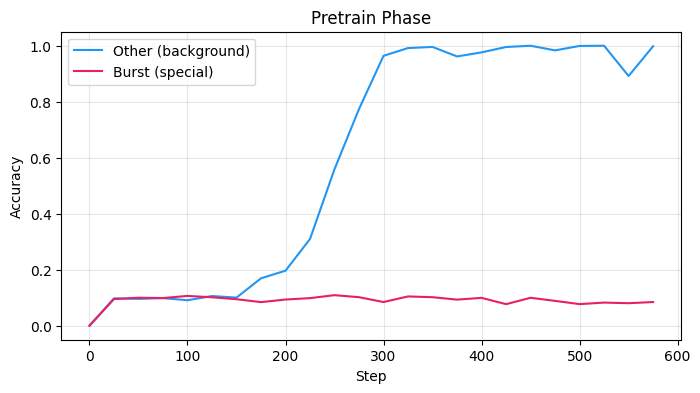

Pretrain ckpt: data/adam_forget/pretrain/pretrain_ckpt.pt


In [2]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED, lr=1e-3, batch_size=BATCH_SIZE)
report.plot_pretrain(pt); plt.show()
print(f"Pretrain ckpt: {pt['ckpt_path']}")

## 2. Finetune at four concentrations

Standard AdamW finetuning, using `simple.finetune`.

In [3]:
FRACS = [0.25, 0.5, 0.75, 0.9, 0.95, 1.0]

ft_results = []
for frac in FRACS:
    ft = finetune(
        data, pt["ckpt_path"], f"{OUT}/finetune",
        burst_frac=frac, steps=3000, seed=SEED, lr=1e-4,
        eval_every=100, grad_clip=1, batch_size=BATCH_SIZE, quiet=False,
    )
    ft_results.append(ft)
    print(f"  {ft['tag']}: peak_burst={ft['peak_burst']:.3f}  ckpt={ft['ckpt_path']}")

Finetune burst_25:   0%|          | 0/3000 [00:00<?, ?it/s]

  burst_25: peak_burst=1.000  ckpt=data/adam_forget/finetune/burst_25_ckpt.pt


Finetune burst_50:   0%|          | 0/3000 [00:00<?, ?it/s]

  burst_50: peak_burst=1.000  ckpt=data/adam_forget/finetune/burst_50_ckpt.pt


Finetune burst_75:   0%|          | 0/3000 [00:00<?, ?it/s]

...

  burst_90: peak_burst=1.000  ckpt=data/adam_forget/finetune/burst_90_ckpt.pt


Finetune burst_95:   0%|          | 0/3000 [00:00<?, ?it/s]

  burst_95: peak_burst=1.000  ckpt=data/adam_forget/finetune/burst_95_ckpt.pt


Finetune burst_100:   0%|          | 0/3000 [00:00<?, ?it/s]

  burst_100: peak_burst=1.000  ckpt=data/adam_forget/finetune/burst_100_ckpt.pt


## 3. Forget with AdamW (c=0) and log 8b-style Taylor terms

For each finetuned checkpoint we run a short AdamW forget with `eval_every=1`, logging per-step `T_first`, `T_second`, `pred_dL`, and `dL_actual` measured on `eval_burst`.

In [4]:
FG_STEPS = 50
FG_LR = 2e-5
FG_EVAL_EVERY = 1
GRAD_CLIP = 0.0        # disabled so pred ΔL tracks the true step exactly

forget_runs = {}
for ft in ft_results:
    frac = ft["burst_frac"]
    print(f"\n===== AdamW forget from c={frac} =====")
    net = load_model(ft["ckpt_path"], data["vocab_size"], data["context_size"],
                     compile_model=False)
    out = adam_forget_with_taylor(
        data, net,
        c=0.0, steps=FG_STEPS, lr=FG_LR, lr_end=FG_LR * 0.5,
        batch_size=BATCH_SIZE, eval_every=FG_EVAL_EVERY, seed=SEED + 1,
        grad_clip=GRAD_CLIP, measure_batch_size=1024,
        desc=f"adam-forget c={frac}",
    )
    forget_runs[frac] = out


===== AdamW forget from c=0.25 =====


adam-forget c=0.25:   0%|          | 0/50 [00:00<?, ?it/s]


===== AdamW forget from c=0.5 =====


adam-forget c=0.5:   0%|          | 0/50 [00:00<?, ?it/s]


===== AdamW forget from c=0.75 =====


...

adam-forget c=0.9:   0%|          | 0/50 [00:00<?, ?it/s]


===== AdamW forget from c=0.95 =====


adam-forget c=0.95:   0%|          | 0/50 [00:00<?, ?it/s]


===== AdamW forget from c=1.0 =====


adam-forget c=1.0:   0%|          | 0/50 [00:00<?, ?it/s]

## 4. 8b-style Taylor plots, one per concentration

Four panels per figure:

- **(0,0)** Stacked area: 1st-order $T_{\mathrm{first}}$ + 2nd-order $T_{\mathrm{second}}$ per step, with actual $\Delta L_{\mathrm{ft}}$ overlaid.
- **(0,1)** Fraction $|T_{\mathrm{first}}|$ vs $|T_{\mathrm{second}}|$ — which order dominates at each step.
- **(1,0)** Per-step predicted (`T1+T2`) vs actual, plus $T_{\mathrm{first}}$-only for reference.
- **(1,1)** Cumulative: actual, predicted, and each term individually.

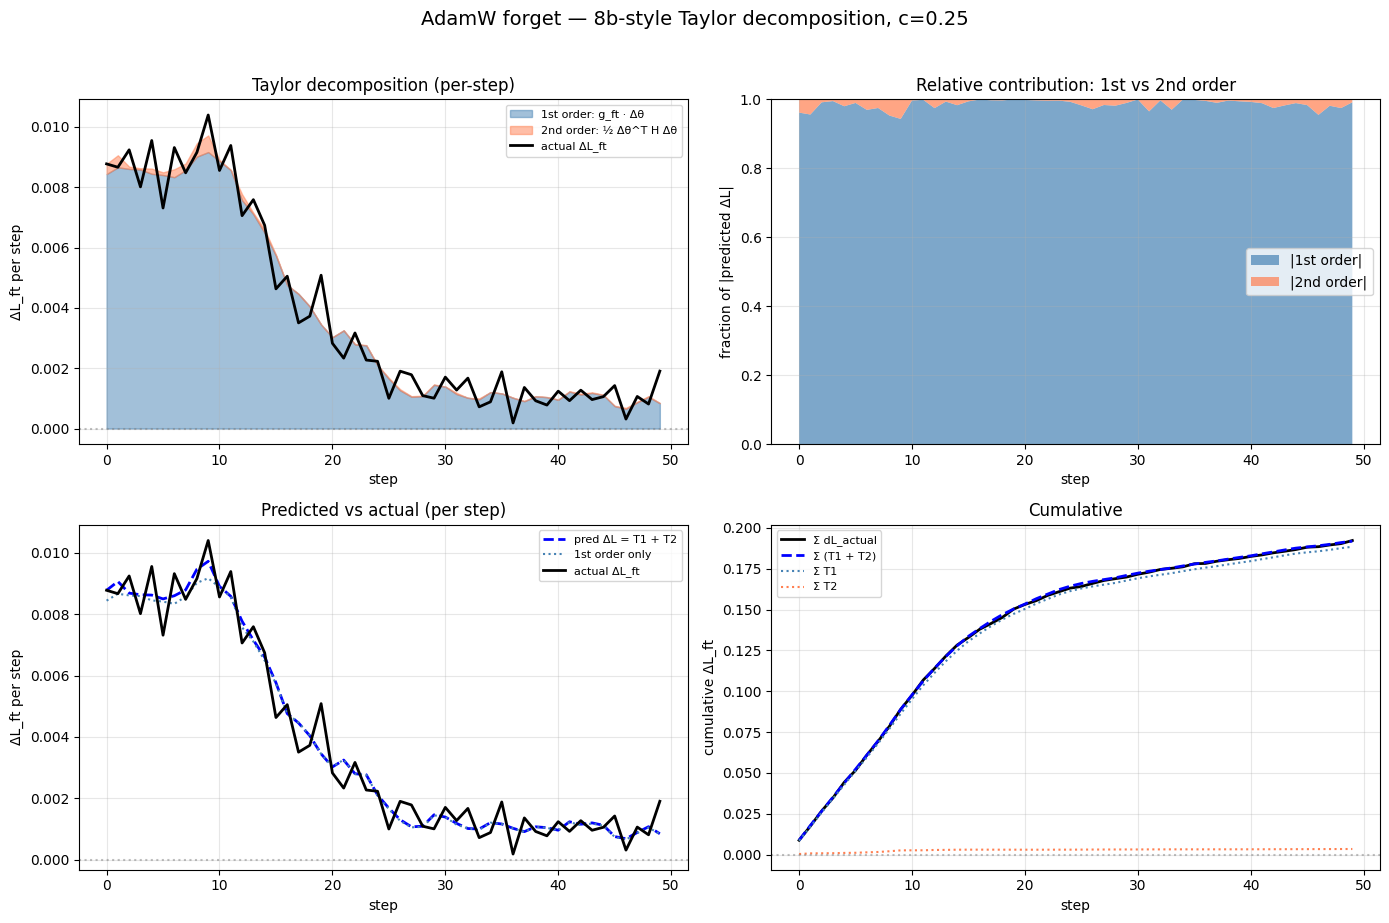

c=0.25:  Σ T1=+0.1884  Σ T2=+0.0034  Σ pred=+0.1918  Σ actual=+0.1922  ⟨|T1| frac⟩=0.99  ⟨|T2| frac⟩=0.01


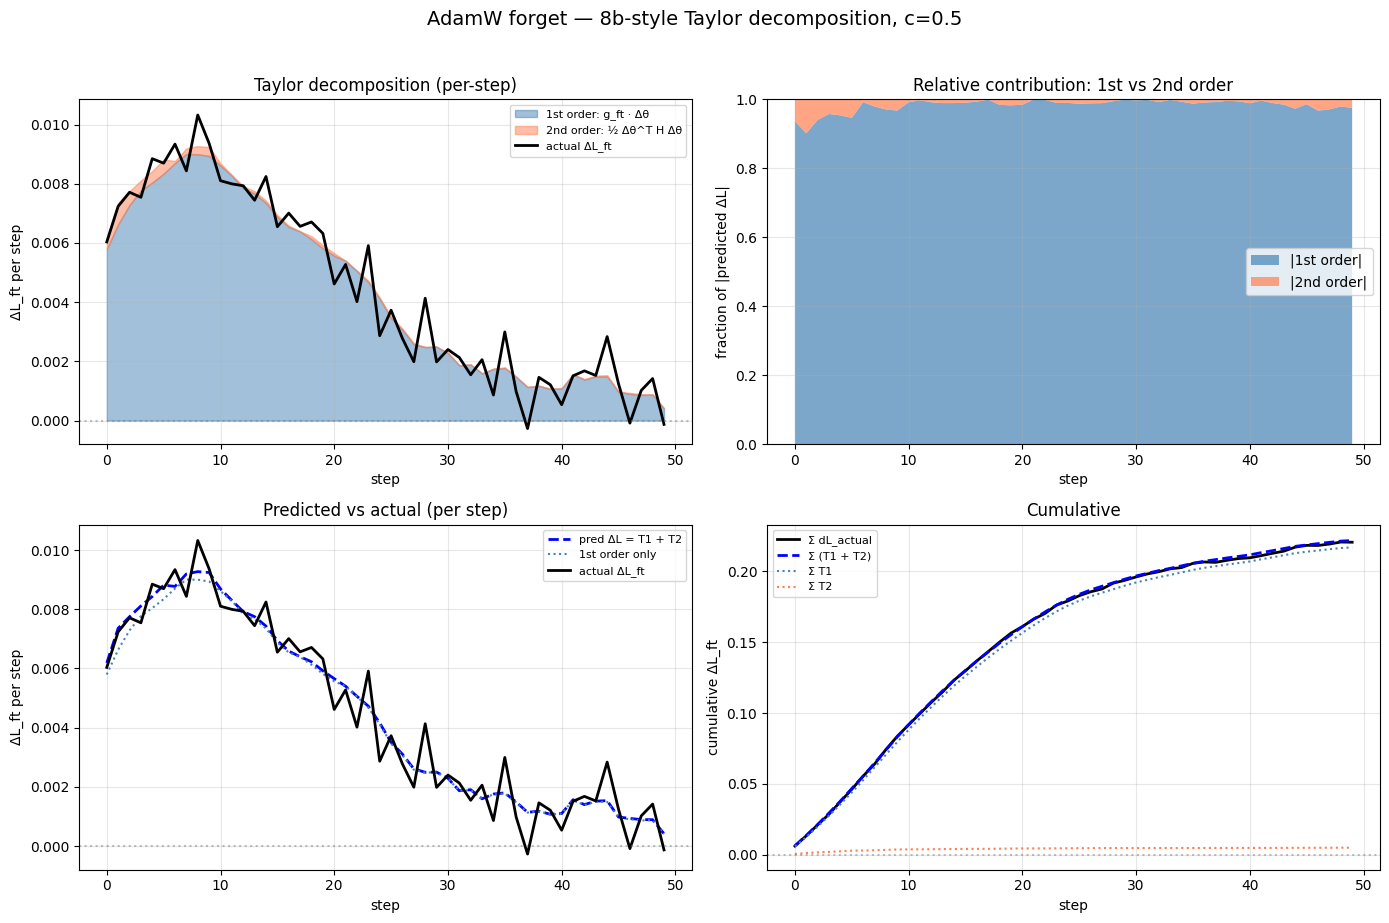

c=0.5:  Σ T1=+0.2169  Σ T2=+0.0049  Σ pred=+0.2218  Σ actual=+0.2206  ⟨|T1| frac⟩=0.98  ⟨|T2| frac⟩=0.02


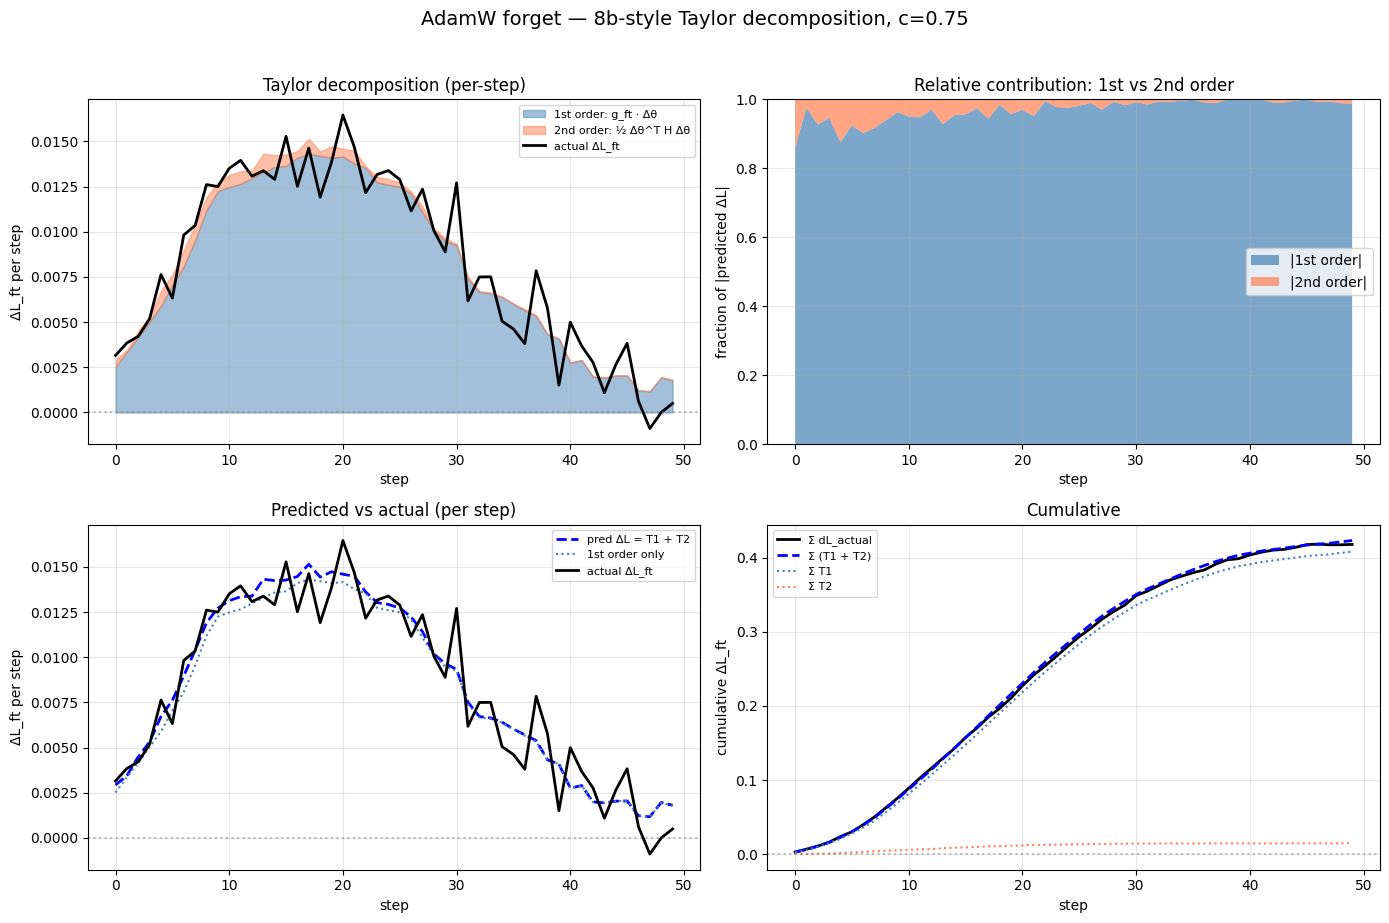

c=0.75:  Σ T1=+0.4081  Σ T2=+0.0149  Σ pred=+0.4230  Σ actual=+0.4177  ⟨|T1| frac⟩=0.97  ⟨|T2| frac⟩=0.03


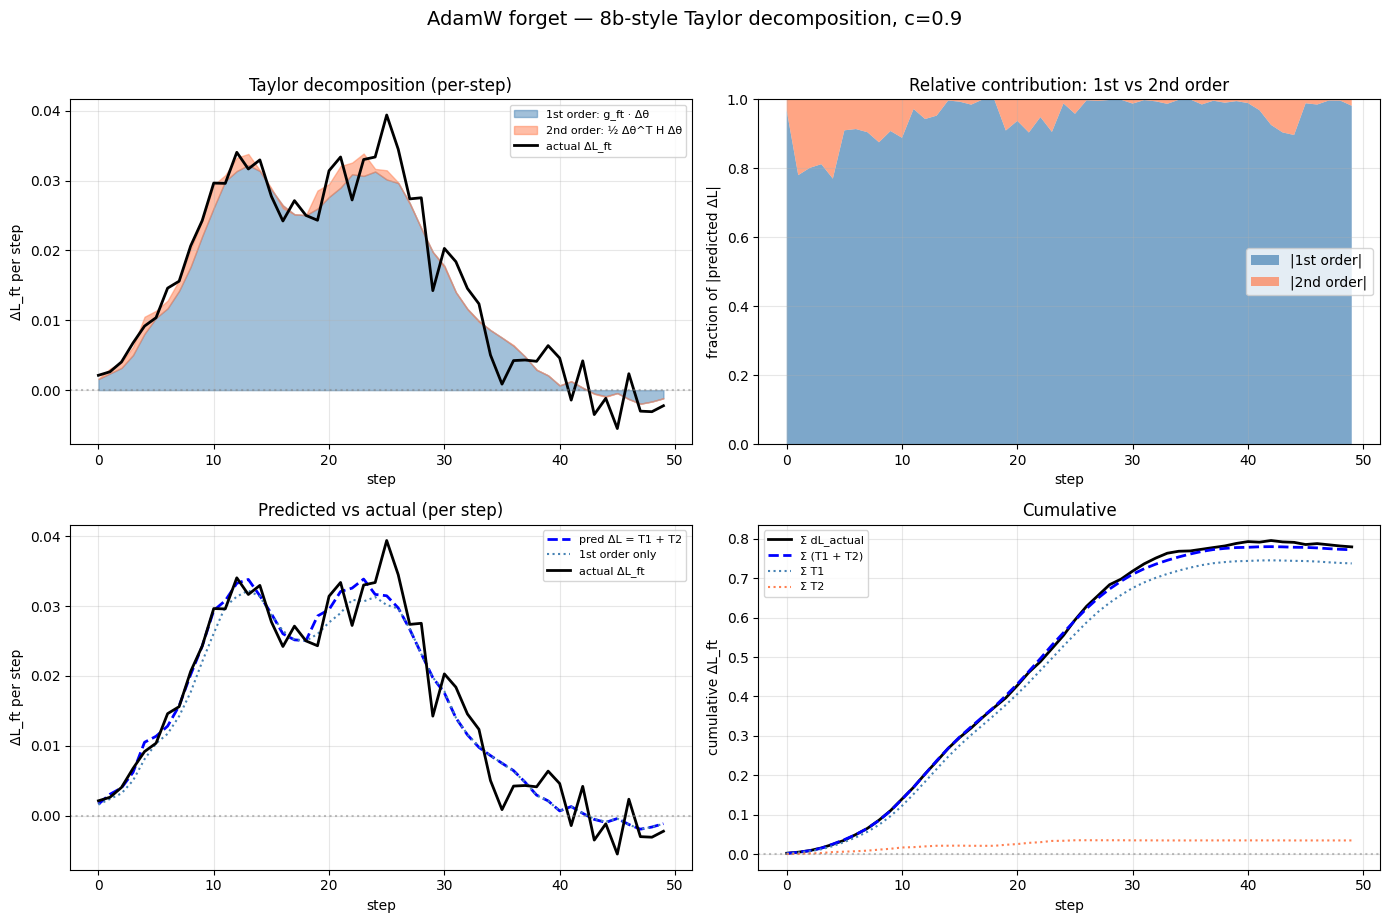

c=0.9:  Σ T1=+0.7376  Σ T2=+0.0346  Σ pred=+0.7722  Σ actual=+0.7795  ⟨|T1| frac⟩=0.95  ⟨|T2| frac⟩=0.05


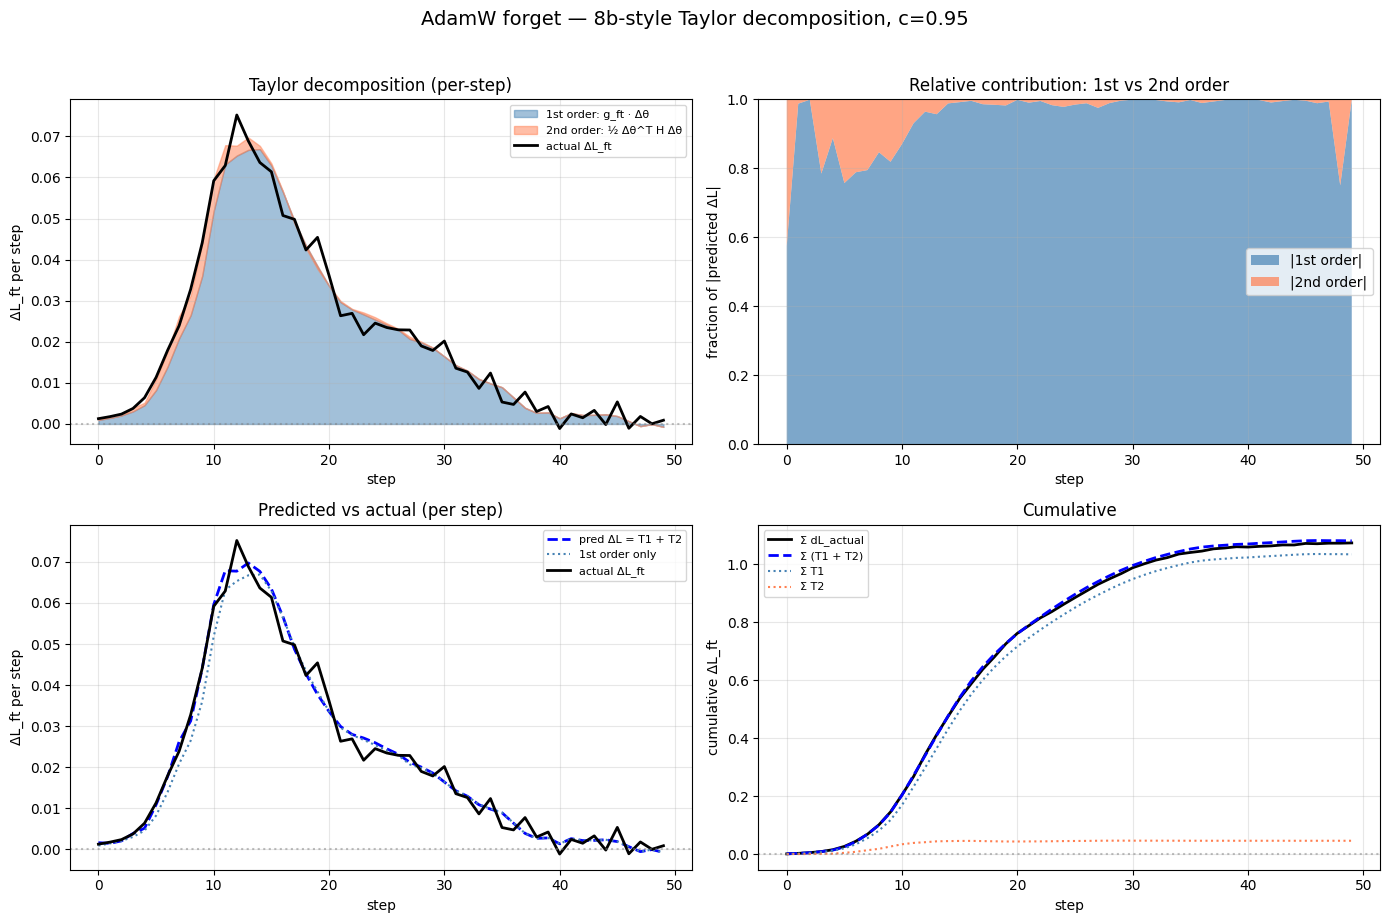

c=0.95:  Σ T1=+1.0334  Σ T2=+0.0465  Σ pred=+1.0799  Σ actual=+1.0728  ⟨|T1| frac⟩=0.95  ⟨|T2| frac⟩=0.05


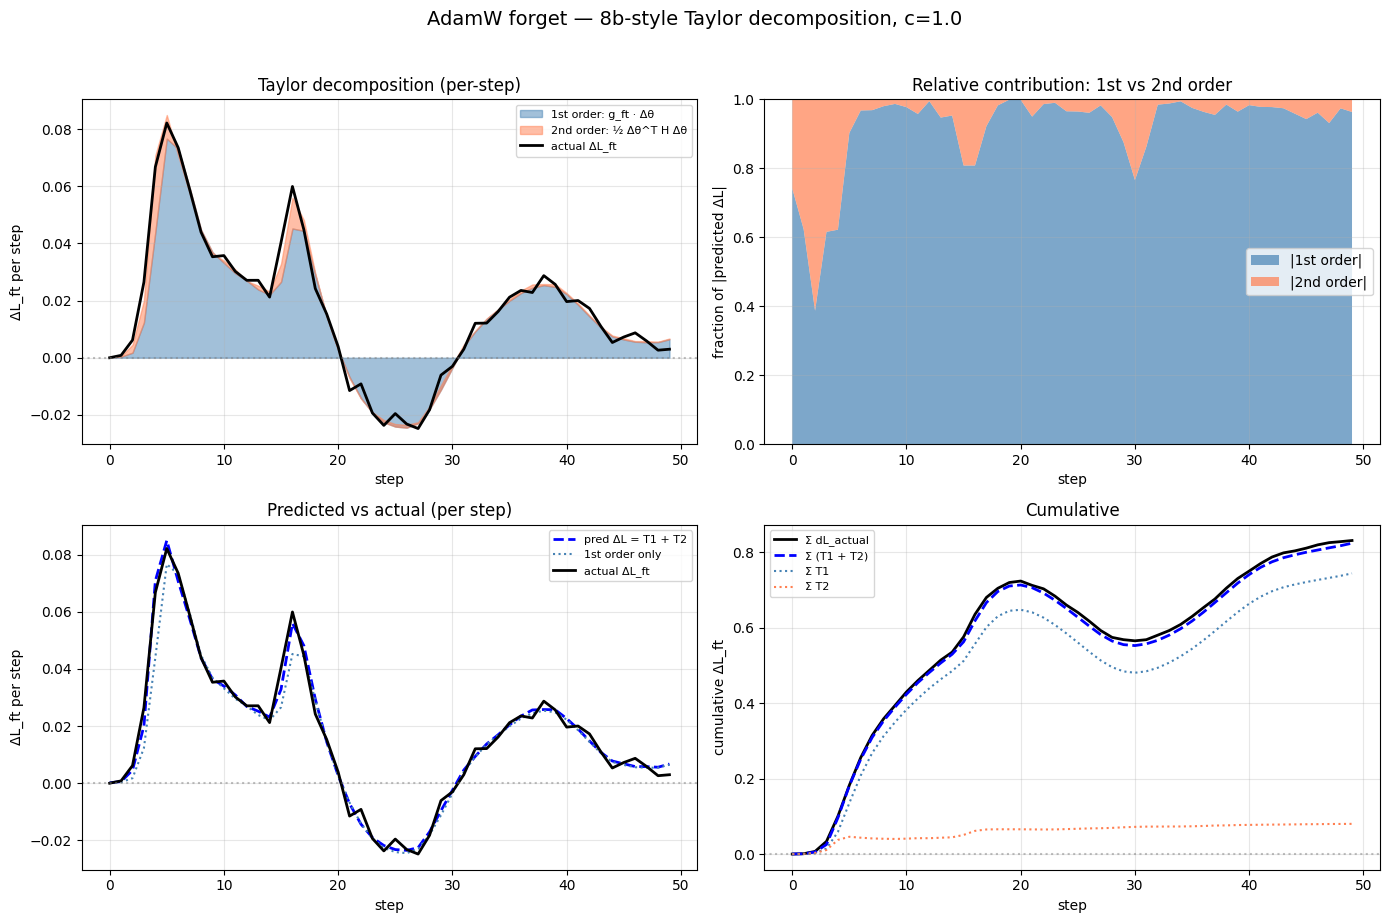

c=1.0:  Σ T1=+0.7440  Σ T2=+0.0800  Σ pred=+0.8240  Σ actual=+0.8311  ⟨|T1| frac⟩=0.92  ⟨|T2| frac⟩=0.08


In [5]:
for frac in sorted(forget_runs):
    log = forget_runs[frac]["log"]
    s = np.asarray(log["step"])
    mask = s >= 0
    x = s[mask]
    T1 = np.nan_to_num(log["T_first"][mask])
    T2 = np.nan_to_num(log["T_second"][mask])
    pred = T1 + T2
    actual = np.nan_to_num(log["dL_actual"][mask])

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0, 0]
    ax.fill_between(x, 0, T1, alpha=0.5, color="steelblue", label="1st order: g_ft · Δθ")
    ax.fill_between(x, T1, T1 + T2, alpha=0.5, color="coral",
                    label="2nd order: ½ Δθ^T H Δθ")
    ax.plot(x, actual, "k-", lw=2, label="actual ΔL_ft")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("step"); ax.set_ylabel("ΔL_ft per step")
    ax.set_title("Taylor decomposition (per-step)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    tot = np.abs(T1) + np.abs(T2)
    safe = np.where(tot > 0, tot, 1.0)
    f1 = np.abs(T1) / safe
    f2 = np.abs(T2) / safe
    ax.stackplot(x, f1, f2, labels=["|1st order|", "|2nd order|"],
                 colors=["steelblue", "coral"], alpha=0.7)
    ax.set_ylim(0, 1); ax.set_xlabel("step")
    ax.set_ylabel("fraction of |predicted ΔL|")
    ax.set_title("Relative contribution: 1st vs 2nd order")
    ax.legend(loc="center right"); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(x, pred,   "b--", lw=2, label="pred ΔL = T1 + T2")
    ax.plot(x, T1,     "steelblue", ls=":", lw=1.5, label="1st order only")
    ax.plot(x, actual, "k-",  lw=2, label="actual ΔL_ft")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("step"); ax.set_ylabel("ΔL_ft per step")
    ax.set_title("Predicted vs actual (per step)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    cum_actual = np.nancumsum(actual)
    cum_pred = np.cumsum(pred)
    cum_T1 = np.cumsum(T1)
    cum_T2 = np.cumsum(T2)
    ax.plot(x, cum_actual, "k-",  lw=2, label="Σ dL_actual")
    ax.plot(x, cum_pred,   "b--", lw=2, label="Σ (T1 + T2)")
    ax.plot(x, cum_T1, "steelblue", ls=":", lw=1.5, label="Σ T1")
    ax.plot(x, cum_T2, "coral",     ls=":", lw=1.5, label="Σ T2")
    ax.axhline(0, color="gray", ls=":", alpha=0.5)
    ax.set_xlabel("step"); ax.set_ylabel("cumulative ΔL_ft")
    ax.set_title("Cumulative")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    fig.suptitle(f"AdamW forget — 8b-style Taylor decomposition, c={frac}", y=1.02, fontsize=14)
    fig.tight_layout(); plt.show()

    print(f"c={frac}:  Σ T1={cum_T1[-1]:+.4f}  Σ T2={cum_T2[-1]:+.4f}  "
          f"Σ pred={cum_pred[-1]:+.4f}  Σ actual={cum_actual[-1]:+.4f}  "
          f"⟨|T1| frac⟩={np.nanmean(f1):.2f}  ⟨|T2| frac⟩={np.nanmean(f2):.2f}")

## 4b. First vs second order contributions across concentrations (first N forget steps)

Where does forgetting *come from* in the very first few steps? Split each step's ΔL_ft into its 1st-order ($g_{\mathrm{ft}}\cdot\Delta\theta$) and 2nd-order ($\tfrac12\Delta\theta^\top H\Delta\theta$) pieces, then aggregate across concentrations.

- Left panel: cumulative Σ T_first and Σ T_second over the first `N_FIRST` steps, per concentration. Black bars are the actual Σ ΔL_ft on the same fixed eval batch for reference.
- Right panel: per-step T_first (solid) and T_second (dashed) for each concentration, so you can see how the 1st/2nd split evolves in the first few steps.


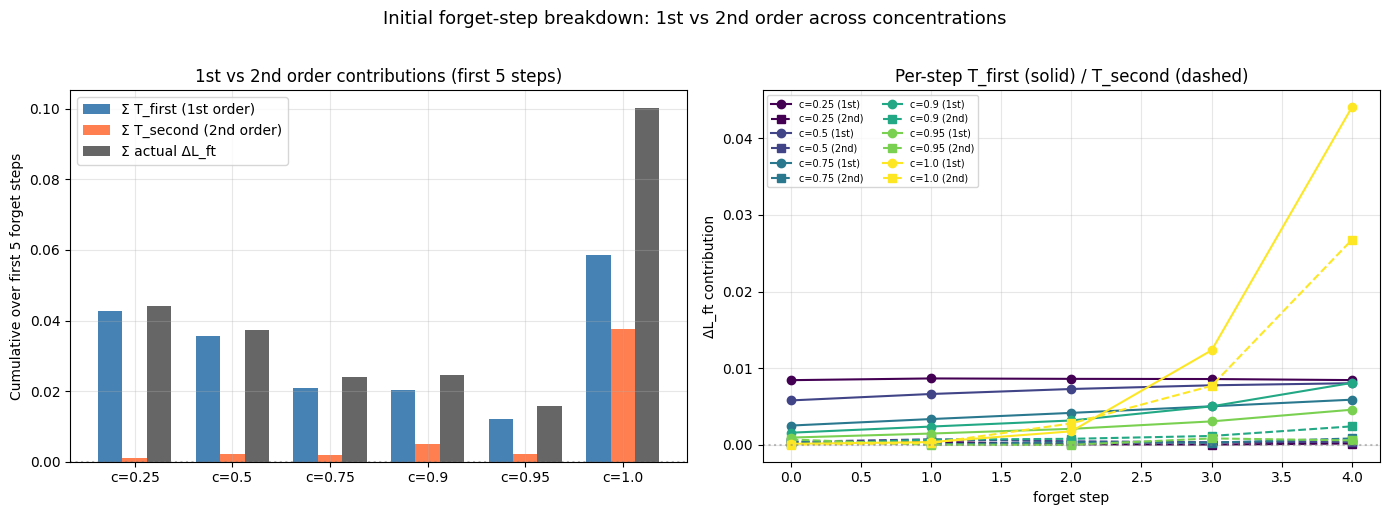


Cumulative over first 5 forget steps:
     c     Σ T_first    Σ T_second        Σ pred      Σ actual
  0.25      +0.04274      +0.00103      +0.04377      +0.04425
  0.50      +0.03552      +0.00231      +0.03784      +0.03738
  0.75      +0.02097      +0.00195      +0.02292      +0.02405
  0.90      +0.02026      +0.00509      +0.02534      +0.02470
  0.95      +0.01216      +0.00214      +0.01430      +0.01566
  1.00      +0.05864      +0.03752      +0.09616      +0.10022


In [6]:
N_FIRST =5 # number of initial forget steps to analyze

fracs_sorted = sorted(forget_runs)
_cmap_init = plt.get_cmap("viridis")
colors_init = {f: _cmap_init(i / max(1, len(fracs_sorted)-1)) for i, f in enumerate(fracs_sorted)}

T1_sums, T2_sums, dL_sums = [], [], []
for c in fracs_sorted:
    log = forget_runs[c]["log"]
    mask = log["step"] >= 0
    T1 = np.nan_to_num(log["T_first"][mask])[:N_FIRST]
    T2 = np.nan_to_num(log["T_second"][mask])[:N_FIRST]
    dL = np.nan_to_num(log["dL_actual"][mask])[:N_FIRST]
    T1_sums.append(T1.sum())
    T2_sums.append(T2.sum())
    dL_sums.append(dL.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 0: grouped bars per concentration ---
ax = axes[0]
x_pos = np.arange(len(fracs_sorted))
w = 0.25
ax.bar(x_pos - w, T1_sums, width=w, color="steelblue",
       label="Σ T_first (1st order)")
ax.bar(x_pos,     T2_sums, width=w, color="coral",
       label="Σ T_second (2nd order)")
ax.bar(x_pos + w, dL_sums, width=w, color="black", alpha=0.6,
       label="Σ actual ΔL_ft")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_xticks(x_pos); ax.set_xticklabels([f"c={f}" for f in fracs_sorted])
ax.set_ylabel(f"Cumulative over first {N_FIRST} forget steps")
ax.set_title(f"1st vs 2nd order contributions (first {N_FIRST} steps)")
ax.legend(); ax.grid(True, alpha=0.3)

# --- Panel 1: per-step trajectories for first N steps ---
ax = axes[1]
for c in fracs_sorted:
    log = forget_runs[c]["log"]
    mask = log["step"] >= 0
    T1 = np.nan_to_num(log["T_first"][mask])[:N_FIRST]
    T2 = np.nan_to_num(log["T_second"][mask])[:N_FIRST]
    s_ax = np.arange(len(T1))
    ax.plot(s_ax, T1, color=colors_init[c], lw=1.5, marker="o",
            label=f"c={c} (1st)")
    ax.plot(s_ax, T2, color=colors_init[c], lw=1.5, marker="s",
            ls="--", label=f"c={c} (2nd)")
ax.axhline(0, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("forget step"); ax.set_ylabel("ΔL_ft contribution")
ax.set_title(f"Per-step T_first (solid) / T_second (dashed)")
ax.legend(fontsize=7, ncol=2, loc="best"); ax.grid(True, alpha=0.3)

fig.suptitle(f"Initial forget-step breakdown: 1st vs 2nd order across concentrations",
             y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

# Numeric summary
print(f"\nCumulative over first {N_FIRST} forget steps:")
print(f"{'c':>6s}  {'Σ T_first':>12s}  {'Σ T_second':>12s}  {'Σ pred':>12s}  {'Σ actual':>12s}")
for c, t1, t2, dl in zip(fracs_sorted, T1_sums, T2_sums, dL_sums):
    print(f"{c:>6.2f}  {t1:>+12.5f}  {t2:>+12.5f}  {t1+t2:>+12.5f}  {dl:>+12.5f}")


In [7]:
T1_sums

[np.float64(0.042742897756397724),
 np.float64(0.035523951053619385),
 np.float64(0.02097422513179481),
 np.float64(0.02025512547697872),
 np.float64(0.012160658137872815),
 np.float64(0.05864094269054476)]

### 4b.ii — Normalized 1st / 2nd order contributions per concentration

Same data, rescaled: for each c we show $|Σ T_{\mathrm{first}}|$ and $|Σ T_{\mathrm{second}}|$ as fractions of their sum. Bars stack to 1. Lets you compare the 1st-vs-2nd-order *balance* across concentrations without magnitude differences confusing the picture.


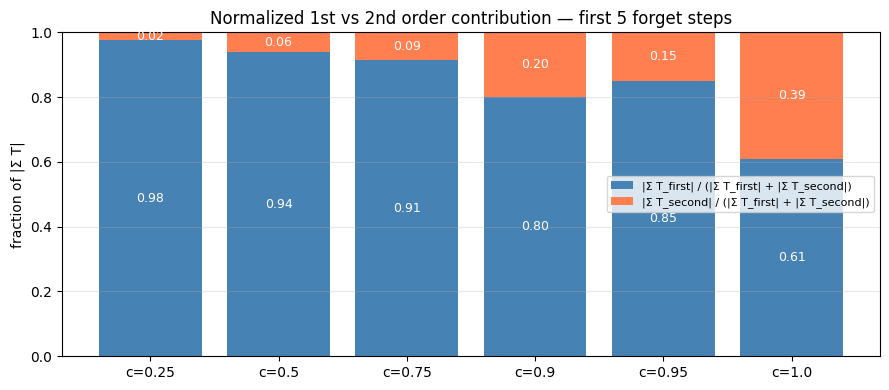

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
abs_T1 = np.abs(T1_sums)
abs_T2 = np.abs(T2_sums)
total = abs_T1 + abs_T2
safe = np.where(total > 0, total, 1.0)
frac_T1 = abs_T1 / safe
frac_T2 = abs_T2 / safe

x_pos = np.arange(len(fracs_sorted))
ax.bar(x_pos, frac_T1, color="steelblue", label="|Σ T_first| / (|Σ T_first| + |Σ T_second|)")
ax.bar(x_pos, frac_T2, bottom=frac_T1, color="coral",
       label="|Σ T_second| / (|Σ T_first| + |Σ T_second|)")
# Annotate each bar with the actual fractions
for i, (f1, f2) in enumerate(zip(frac_T1, frac_T2)):
    ax.text(i, f1/2, f"{f1:.2f}", ha="center", va="center", fontsize=9, color="white")
    ax.text(i, f1 + f2/2, f"{f2:.2f}", ha="center", va="center", fontsize=9, color="white")

ax.set_xticks(x_pos); ax.set_xticklabels([f"c={f}" for f in fracs_sorted])
ax.set_ylim(0, 1); ax.set_ylabel("fraction of |Σ T|")
ax.set_title(f"Normalized 1st vs 2nd order contribution — first {N_FIRST} forget steps")
ax.legend(loc="center right", fontsize=8); ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout(); plt.show()


## 5. Loss / accuracy trajectories — finetune → forget

Full trajectory for each concentration across both phases on one plot. Dashed vertical line marks the finetune → forget boundary.


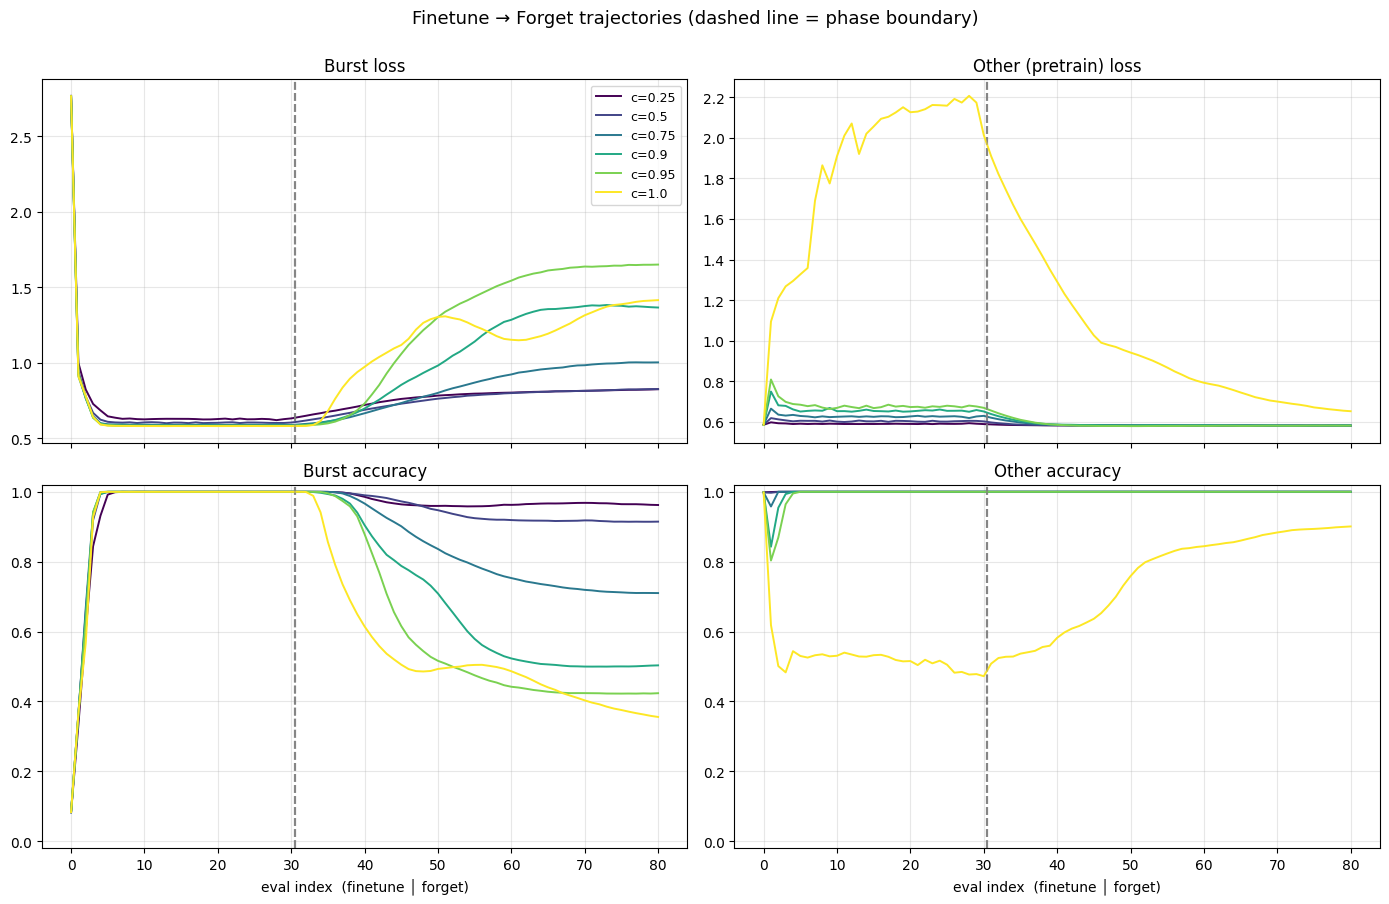

In [9]:
cmap = plt.get_cmap("viridis")
colors = {f: cmap(i / max(1, len(FRACS) - 1)) for i, f in enumerate(sorted(FRACS))}

ft_logs = {ft["burst_frac"]: ft["log"] for ft in ft_results}

def _concat(ft_log, fg_log, key):
    ft_arr = np.asarray(ft_log[key])
    fg_arr = np.asarray(fg_log[key])
    y = np.concatenate([ft_arr, fg_arr])
    x = np.arange(len(y))
    split = len(ft_arr)
    return x, y, split

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for frac in sorted(forget_runs):
    ft_log = ft_logs[frac]
    fg_log = forget_runs[frac]["log"]
    col = colors[frac]
    for ax, key in zip(axes.flat, ["loss_burst", "loss_other", "acc_burst", "acc_other"]):
        x, y, split = _concat(ft_log, fg_log, key)
        ax.plot(x, y, color=col, lw=1.4, label=f"c={frac}")
        ax.axvline(split - 0.5, color="gray", ls="--", alpha=0.4)

for ax, title in zip(axes.flat,
                     ["Burst loss", "Other (pretrain) loss",
                      "Burst accuracy", "Other accuracy"]):
    ax.set_title(title); ax.grid(True, alpha=0.3)
    if title.endswith("accuracy"):
        ax.set_ylim(-0.02, 1.02)
axes[0, 0].legend(fontsize=9, loc="best")
for ax in axes[-1]:
    ax.set_xlabel("eval index  (finetune │ forget)")
fig.suptitle("Finetune → Forget trajectories (dashed line = phase boundary)",
             y=1.0, fontsize=13)
fig.tight_layout(); plt.show()


## 6. Summary table

In [10]:
print(f"{'c':>5s}  {'ft_end ab':>9s}  {'fg_end lb':>10s} {'fg_end ab':>9s}  "
      f"{'Δab':>8s}  {'Σ T1':>10s} {'Σ T2':>10s} {'Σ pred':>10s}  {'Σ actual':>10s}")
for frac in sorted(forget_runs):
    ft = [x for x in ft_results if x['burst_frac'] == frac][0]
    log = forget_runs[frac]["log"]; mask = log["step"] >= 0
    T1 = np.nansum(log["T_first"][mask])
    T2 = np.nansum(log["T_second"][mask])
    pred = T1 + T2
    actual = np.nansum(log["dL_actual"][mask])
    d_ab = log["acc_burst"][-1] - ft["peak_burst"]
    print(f"{frac:>5.2f}  {ft['peak_burst']:>9.3f}  "
          f"{log['loss_burst'][-1]:>10.4f} {log['acc_burst'][-1]:>9.3f}  {d_ab:>+8.3f}  "
          f"{T1:>+10.4f} {T2:>+10.4f} {pred:>+10.4f}  {actual:>+10.4f}")

    c  ft_end ab   fg_end lb fg_end ab       Δab        Σ T1       Σ T2     Σ pred    Σ actual
 0.25      1.000      0.8256     0.962    -0.038     +0.1884    +0.0034    +0.1918     +0.1922
 0.50      1.000      0.8261     0.915    -0.085     +0.2169    +0.0049    +0.2218     +0.2206
 0.75      1.000      1.0032     0.710    -0.290     +0.4081    +0.0149    +0.4230     +0.4177
 0.90      1.000      1.3667     0.503    -0.497     +0.7376    +0.0346    +0.7722     +0.7795
 0.95      1.000      1.6512     0.423    -0.577     +1.0334    +0.0465    +1.0799     +1.0728
 1.00      1.000      1.4156     0.355    -0.645     +0.7440    +0.0800    +0.8240     +0.8311


## Paper section: per-step Taylor decomposition of forgetting

### Experimental setup

We study how the AdamW forgetting trajectory decomposes into first- and second-order contributions, across a range of finetuning concentrations. The experiment proceeds in three stages:

1. **Pretrain**. A small transformer is trained on the background task until convergence.
2. **Finetune at concentration $c$**. Starting from the same pretrained checkpoint, we run AdamW finetuning on mixed batches that contain a fraction $c$ of burst examples and $1-c$ of pretraining examples, for $c \in \{0.25, 0.5, 0.75, 0.9, 0.95, 1.0\}$. This produces one finetuned checkpoint per $c$.
3. **Forget**. From each finetuned checkpoint we resume AdamW training on pure pretraining batches ($c=0$) and observe how the burst performance degrades.

Throughout the forget stage we log, at every optimizer step, the two leading terms in the Taylor expansion of the burst-loss change:

$$\Delta L_{\mathrm{burst}}(\theta_t \to \theta_{t+1}) \;\approx\; \underbrace{g_{\mathrm{burst}}(\theta_t)^\top \Delta\theta}_{T_{\mathrm{first}}} \;+\; \underbrace{\tfrac{1}{2}\, \Delta\theta^\top H_{\mathrm{burst}}(\theta_t)\, \Delta\theta}_{T_{\mathrm{second}}},$$

where $\Delta\theta = \theta_{t+1} - \theta_t$ is the *actual* parameter change produced by AdamW, $g_{\mathrm{burst}}$ is the gradient of burst loss on a held-out eval set, and $H_{\mathrm{burst}} \Delta\theta$ is computed via one finite-difference Hessian-vector product per step on the same held-out set. This decomposition is optimizer-agnostic: $T_{\mathrm{first}}$ and $T_{\mathrm{second}}$ quantify how the geometry of the burst loss reacts to whatever step the optimizer takes, regardless of momentum or preconditioning.

### Reading the figure

Each row of the figure corresponds to one finetuning concentration (low $c$ at the top, high $c$ at the bottom). Columns show two views of the same per-step quantities:

- **Left column — magnitudes.** Stacked area plots of $T_{\mathrm{first}}$ (blue) and $T_{\mathrm{second}}$ (coral), overlaid with the directly measured $\Delta L_{\mathrm{burst}}$ (black). All rows share a common $y$-axis so the size of the effect is directly comparable across concentrations.
- **Right column — relative contribution.** Normalized stacked area of $|T_{\mathrm{first}}| / (|T_{\mathrm{first}}| + |T_{\mathrm{second}}|)$ and $|T_{\mathrm{second}}| / (|T_{\mathrm{first}}| + |T_{\mathrm{second}}|)$, which tells us *which order of the Taylor expansion is responsible* for the observed loss change at each step.

### Headline finding

The composition of forgetting changes systematically with finetuning concentration. At low $c$, the model ends finetuning far from the burst minimum: $g_{\mathrm{burst}}$ is already large, and the very first pretraining step produces a substantial first-order loss change. Forgetting is *alignment-driven* and roughly at its steady-state rate from step one. At high $c$, finetuning drives the model close to the burst minimum where $g_{\mathrm{burst}} \approx 0$; the first-order contribution vanishes and initial forgetting is entirely *curvature-driven* (second-order). Only after several steps — as the parameters drift far enough to regenerate a non-trivial $g_{\mathrm{burst}}$ — does the first-order term reemerge and forgetting accelerate to its eventual rate. This "warm-up" transient is visible as a low-magnitude, second-order-dominated regime in the top-left rows of the figure, and it is absent at low $c$.


saved: data/adam_forget/figures/fig_per_concentration_taylor.pdf


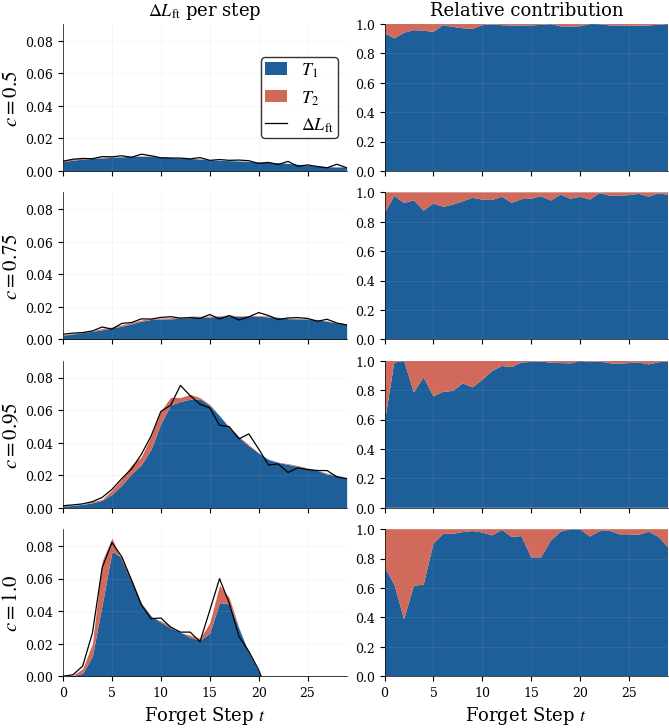

In [11]:
# ---- knobs --------------------------------------------------------------
MAX_STEP      = 30           # plot up to this forget step (None → use all)
EXCLUDE_FRACS = [0.25, 0.9]           # e.g. [0.9] to drop a concentration from the grid
SAVE_PATH     = "data/adam_forget/figures/fig_per_concentration_taylor"  # .pdf appended
# -------------------------------------------------------------------------

# Load paper style from notebooks/style.py — preserve the notebook's display
# backend (the module forces "Agg" on import, which would disable inline plots).
import sys, importlib.util, matplotlib as mpl
_orig_backend = mpl.get_backend()
_style_spec = importlib.util.spec_from_file_location("_paper_style", "notebooks/style.py")
_style_mod  = importlib.util.module_from_spec(_style_spec)
_style_spec.loader.exec_module(_style_mod)
mpl.use(_orig_backend, force=True)
_style_mod.apply_paper_style()
# Bump tick label size for on-screen / poster use while keeping the rest of the
# paper style. Adjust TICK_SIZE to taste.
TICK_SIZE = 9
plt.rcParams.update({
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
})

# ---- data -----------------------------------------------------------------
fracs_plot = [f for f in sorted(forget_runs) if f not in EXCLUDE_FRACS]
nrows = len(fracs_plot)

def _slice(arr, n):
    return arr if n is None else arr[:n]

# Shared y-limits on the left column.
_y_lo, _y_hi = 0.0, 0.0
for c in fracs_plot:
    log = forget_runs[c]["log"]; mask = log["step"] >= 0
    T1 = _slice(np.nan_to_num(log["T_first"][mask]),  MAX_STEP)
    T2 = _slice(np.nan_to_num(log["T_second"][mask]), MAX_STEP)
    a  = _slice(np.nan_to_num(log["dL_actual"][mask]),MAX_STEP)
    _y_hi = max(_y_hi, float(np.maximum.reduce([T1, T1 + T2, a, np.zeros_like(T1)]).max()))
    _y_lo = min(_y_lo, float(np.minimum.reduce([T1, T1 + T2, a, np.zeros_like(T1)]).min()))
_pad = 0.05 * (_y_hi - _y_lo) if _y_hi > _y_lo else 1e-4
_y_lo -= _pad; _y_hi += _pad

# ---- figure ---------------------------------------------------------------
# Full-column width, height scales with nrows (preserves golden-ratio feel).
fig_w, fig_h = _style_mod.figsize("full", nrows=max(nrows * 0.55, 0.55))
fig, axes = plt.subplots(nrows, 2, figsize=(fig_w, fig_h * 0.8), sharex=True, sharey="col")
if nrows == 1:
    axes = axes[None, :]

COL_1ST = "#1f5f99"   # indigo-blue
COL_2ND = "#d16a5a"   # terracotta
COL_ACT = "black"

for i, c in enumerate(fracs_plot):
    log = forget_runs[c]["log"]; mask = log["step"] >= 0
    x  = _slice(np.asarray(log["step"])[mask],                 MAX_STEP)
    T1 = _slice(np.nan_to_num(log["T_first"][mask]),           MAX_STEP)
    T2 = _slice(np.nan_to_num(log["T_second"][mask]),          MAX_STEP)
    a  = _slice(np.nan_to_num(log["dL_actual"][mask]),         MAX_STEP)

    # Left panel: stacked 1st + 2nd with actual overlay.
    ax = axes[i, 0]
    ax.fill_between(x, 0, T1,          color=COL_1ST, linewidth=0,
                    label=(r"$T_{1}$"  if i == 0 else None))
    ax.fill_between(x, T1, T1 + T2,    color=COL_2ND,  linewidth=0,
                    label=(r"$T_{2}$" if i == 0 else None))
    ax.plot(x, a, color=COL_ACT, linewidth=0.9,
            label=(r"$\Delta L_{\mathrm{ft}}$" if i == 0 else None))
    ax.axhline(0, color="0.55", linewidth=0.4)
    ax.set_ylim(_y_lo, _y_hi)
    ax.set_ylabel(rf"$c = {c}$", labelpad=10, fontsize=15, va="center")
    ax.grid(visible=True)
    ax.set_xlim(0, x[-1] if len(x) > 0 else None)
    ax.set_ylim(0, a.max() * 1.1 if len(a) > 0 else None)
    if i == 0:
        #add a grey legend with alpha = 0.5
        ax.set_title(r"$\Delta L_{\mathrm{ft}}$ per step", fontsize=13)
        ax.legend(loc="right", ncol=1, handlelength=1.2, borderpad=0.2,
          columnspacing=1.2, fontsize=13, frameon=True, framealpha=0.8, 
          edgecolor="black", facecolor="white")

    # Right panel: normalized 1st/2nd fractions.
    ax = axes[i, 1]
    tot  = np.abs(T1) + np.abs(T2)
    safe = np.where(tot > 0, tot, 1.0)
    f1, f2 = np.abs(T1) / safe, np.abs(T2) / safe
    ax.stackplot(x, f1, f2, colors=[COL_1ST, COL_2ND], 
                 labels=[r"$T_{1}$", r"$T_{2}$"])
    ax.set_ylim(0, 1)
    ax.grid(visible=True)
    if i == 0:
    #     ax.legend(loc="center right", handlelength=1.2, borderpad=0.2, fontsize=13)
        
        ax.set_title(r"Relative contribution", fontsize=13)

for ax in axes[-1]:
    ax.set_xlabel(r"Forget Step $t$", fontsize=13)

fig.align_ylabels(axes[:, 0])

# Save as PDF for the paper, then display inline.
from pathlib import Path
save_p = Path(SAVE_PATH).with_suffix(".pdf")
save_p.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_p, bbox_inches="tight")
print(f"saved: {save_p}")
plt.show()


## Appendix: why high-$c$ forgetting has a warm-up

Let $\theta^*$ be the burst-loss minimum and $H^* = \nabla^2 L_{\mathrm{ft}}(\theta^*)$ its Hessian at the minimum. For any $\theta$ in a neighbourhood of $\theta^*$,

$$g_{\mathrm{ft}}(\theta) \;=\; H^*\,(\theta - \theta^*) \;+\; O(\|\theta - \theta^*\|^2), \qquad H_{\mathrm{ft}}(\theta) \;=\; H^* + O(\|\theta - \theta^*\|).$$

Let $\Delta\theta_t = \theta_{t+1} - \theta_t$ be the AdamW step at forget step $t$. Two useful scales:

$$\|\Delta\theta\| \;\sim\; \eta\,\sqrt{N} \quad \text{(per-coordinate Adam step is } \sim \eta\text{)}, \qquad \|H^*\|_{\mathrm{op}} \;\approx\; \lambda.$$

Both are approximately constant early in the forget phase. Plugging these in, the two Taylor contributions scale as

$$|T_{\mathrm{first}}(t)| \;=\; |g_{\mathrm{ft}}(\theta_t)^\top \Delta\theta_t| \;\sim\; \lambda\, \|\theta_t - \theta^*\|\, \|\Delta\theta\|\, |\cos\phi_t|,$$

$$|T_{\mathrm{second}}(t)| \;=\; \tfrac12\,\|\Delta\theta_t\|_{H^*}^2 \;\sim\; \lambda\, \|\Delta\theta\|^2,$$

where $\phi_t$ is the angle between $H^*(\theta_t - \theta^*)$ and $\Delta\theta_t$. The key observation is that $T_{\mathrm{first}}$ carries a factor $\|\theta_t - \theta^*\|$ while $T_{\mathrm{second}}$ does not.

### Where does each concentration start?

At the moment forgetting begins, $t = 0$ and $\theta_0 = \theta_{\mathrm{ft}}(c)$. Define

$$r(c) \;:=\; \|\theta_{\mathrm{ft}}(c) - \theta^*\|,$$

the distance from the burst minimum that concentration-$c$ finetuning leaves the model at. Empirically $r(c)$ is a decreasing function of $c$, with $r(1.0) \approx 0$ (pure burst training reaches the minimum) and $r(c) \gg \|\Delta\theta\|$ for $c \lesssim 0.5$.

### The warm-up dynamics

The pretraining gradient has a persistent direction that drives a roughly **coherent drift** rather than a random walk, so

$$\|\theta_t - \theta^*\| \;\approx\; r(c) \;+\; \|\Delta\theta\|\, t \;=\; r(c) + \eta\,\sqrt{N}\, t.$$

Substituting,

$$\boxed{\;\frac{|T_{\mathrm{first}}(t)|}{|T_{\mathrm{second}}(t)|} \;\approx\; |\cos\phi_t|\cdot\frac{r(c) + \eta\,\sqrt{N}\, t}{\|\Delta\theta\|} \;=\; |\cos\phi_t|\left(\frac{r(c)}{\eta\sqrt{N}} + t\right).\;}$$

The ratio grows linearly in $t$ with an **initial offset** $r(c) / \|\Delta\theta\|$ set by the starting distance. Two regimes:

- **Low $c$** ($r(c) \gg \|\Delta\theta\|$): the offset is large, so $|T_{\mathrm{first}}| \gg |T_{\mathrm{second}}|$ from step zero. Forgetting is *alignment-driven and immediate*.
- **High $c$** ($r(c) \to 0$): the offset is tiny, so at $t = 0$ we have $|T_{\mathrm{first}}| \ll |T_{\mathrm{second}}|$. Forgetting is initially *curvature-only*, at the reduced rate $|T_{\mathrm{second}}| \sim \lambda\, \|\Delta\theta\|^2 = O(\eta^2)$.

### Crossover time

In the high-$c$ regime, $T_{\mathrm{first}}$ overtakes $T_{\mathrm{second}}$ when

$$t^*(c) \;\approx\; \frac{1}{|\cos\phi|}\left(1 \;-\; \frac{r(c)}{\eta\sqrt{N}}\right)_+ \;\approx\; \frac{1}{|\cos\phi|} \quad \text{for } c = 1.$$

So the warm-up phase lasts $\mathcal{O}(|\cos\phi|^{-1})$ steps before the trajectory settles into the alignment-driven regime that other concentrations inhabit from step zero.

### Consequence for the total loss change

During warm-up ($t \lesssim t^*$), the per-step $\Delta L$ is $\sim \lambda\, \eta^2$ (purely second-order). After warm-up, it is $\sim \lambda\, \eta^2 \cdot t \cdot |\cos\phi|$ (grows linearly in $t$). At low $c$ the trajectory spends no time in the first regime. The Section 7 figure is a direct picture of $|T_{\mathrm{first}}|/|T_{\mathrm{second}}|$ along each row: it starts at $r(c)/\|\Delta\theta\|$ and grows linearly, so the higher the concentration, the longer the initial coral-dominated band before the blue region takes over.


Below i take the data from the experiment on pythia 70 m

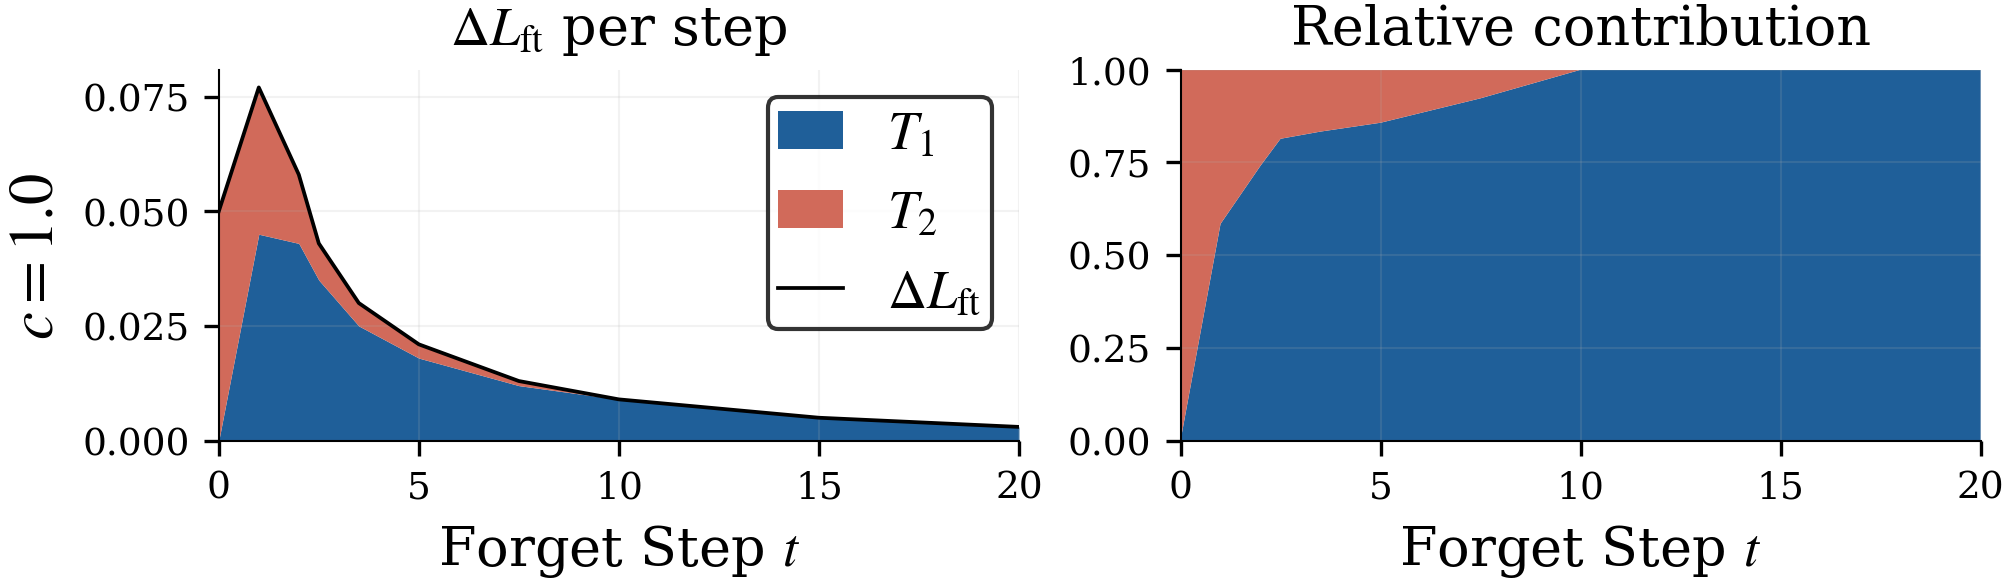

Done


In [12]:
# Data extracted from plots (red series only, blue is ~0)
steps = np.array([0.0, 1.0, 2.0, 2.5, 3.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0])

T2 = np.array([0.000, 0.045, 0.043, 0.035, 0.025, 0.018, 0.012, 0.009, 0.007, 0.005, 0.004, 0.003])
T4 = np.array([0.050, 0.032, 0.015, 0.008, 0.005, 0.003, 0.001, 0.000, 0.000, 0.000, 0.000, 0.000])

total = T2 + T4

# ---- paper style (same as the per-concentration figure above) -----------
import sys, importlib.util, matplotlib as mpl
_orig_backend = mpl.get_backend()
_style_spec = importlib.util.spec_from_file_location("_paper_style", "notebooks/style.py")
_style_mod  = importlib.util.module_from_spec(_style_spec)
_style_spec.loader.exec_module(_style_mod)
mpl.use(_orig_backend, force=True)
_style_mod.apply_paper_style()
TICK_SIZE = 9
plt.rcParams.update({"xtick.labelsize": TICK_SIZE, "ytick.labelsize": TICK_SIZE})

COL_1ST = "#1f5f99"   # indigo-blue  (first-order / conflict)
COL_2ND = "#d16a5a"   # terracotta   (second-order / curvature)
COL_ACT = "black"

fig_w, fig_h = _style_mod.figsize("full", nrows=0.6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_w, fig_h * 0.8), dpi=300)

# --- Left: stacked area ---
ax1.fill_between(steps, 0, T2,        color=COL_1ST, linewidth=0, label=r"$T_1$")
ax1.fill_between(steps, T2, T2 + T4,  color=COL_2ND, linewidth=0, label=r"$T_2$")
ax1.plot(steps, total, color=COL_ACT, linewidth=0.9, label=r"$\Delta L_{\mathrm{ft}}$")
ax1.axhline(0, color="0.55", linewidth=0.4)
ax1.set_xlabel(r"Forget Step $t$", fontsize=13)
ax1.set_ylabel(r"$c = 1.0$", fontsize = 15)
ax1.set_title(r"$\Delta L_{\mathrm{ft}}$ per step", fontsize=13)
ax1.legend(loc="upper right", ncol=1, handlelength=1.2, borderpad=0.2,
           columnspacing=1.2, fontsize=13, frameon=True, framealpha=0.8,
           edgecolor="black", facecolor="white")
ax1.set_xlim(0, 20)
ax1.set_ylim(0)
ax1.grid(visible=True)

# --- Right: relative fractions ---
mask = total > 0
frac_T2 = np.zeros_like(T2)
frac_T4 = np.zeros_like(T4)
frac_T2[mask] = T2[mask] / total[mask]
frac_T4[mask] = T4[mask] / total[mask]

ax2.stackplot(steps, frac_T2, frac_T4, colors=[COL_1ST, COL_2ND],
              labels=[r"$T_1$", r"$T_2$"])
ax2.set_xlabel(r"Forget Step $t$", fontsize=13)
ax2.set_title(r"Relative contribution", fontsize=13)
ax2.set_xlim(0, 20)
ax2.set_ylim(0, 1)
ax2.grid(visible=True)

from pathlib import Path
for out in ("data/adam_forget/figures/pythiacurv.png",
           "data/adam_forget/figures/pythiacurv.pdf"):
    Path(out).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches="tight", dpi=300 if out.endswith(".png") else None)
plt.show()
print("Done")


## Combined figure: (a) per-concentration grid + (b) Pythia 70M

Single paper-ready figure that stacks the two experiments. Panel **(a)** is the per-concentration Taylor decomposition from our nanoGPT sweep; panel **(b)** is the Pythia 70M reproduction. A vertical gap separates them, and bold `(a)` / `(b)` labels are placed in the top-left corner of each panel.


saved: data/adam_forget/figures/fig_combined_ab.pdf
       data/adam_forget/figures/fig_combined_ab.png
       data/adam_forget/figures/fig_combined_ab.pkl


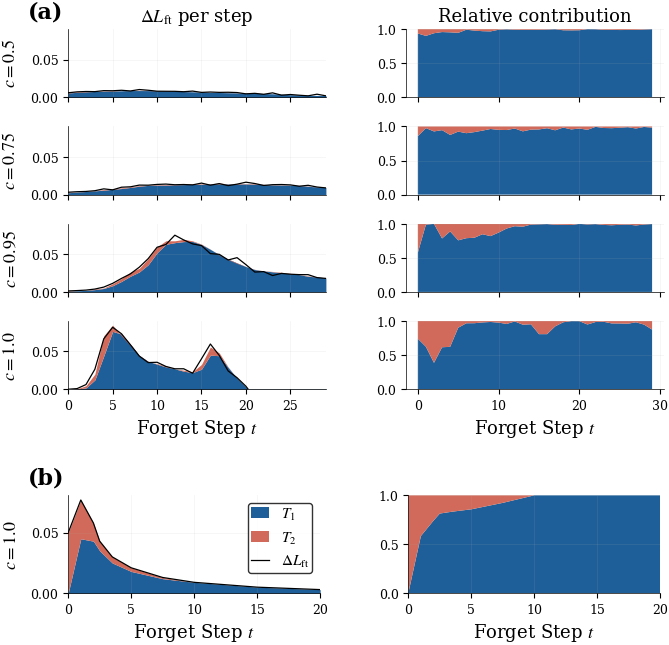

In [13]:
# ---- knobs -------------------------------------------------------------
MAX_STEP      = 30
EXCLUDE_FRACS = [0.25, 0.9]
HEIGHT_SCALE  = 1.7         # multiply all row heights (1.0 = original, bigger → taller rows)
SAVE_PATH     = "data/adam_forget/figures/fig_combined_ab"
# ------------------------------------------------------------------------

import sys, importlib.util, matplotlib as mpl
from matplotlib.gridspec import GridSpec
_orig_backend = mpl.get_backend()
_style_spec = importlib.util.spec_from_file_location("_paper_style", "notebooks/style.py")
_style_mod  = importlib.util.module_from_spec(_style_spec)
_style_spec.loader.exec_module(_style_mod)
mpl.use(_orig_backend, force=True)
_style_mod.apply_paper_style()
TICK_SIZE = 9
plt.rcParams.update({"xtick.labelsize": TICK_SIZE, "ytick.labelsize": TICK_SIZE})

COL_1ST = "#1f5f99"   # indigo-blue
COL_2ND = "#d16a5a"   # terracotta
COL_ACT = "black"

# ── Panel A data ────────────────────────────────────────────────────────
fracs_plot = [f for f in sorted(forget_runs) if f not in EXCLUDE_FRACS]
nrows_a = len(fracs_plot)

def _slice(arr, n): return arr if n is None else arr[:n]

_y_lo, _y_hi = 0.0, 0.0
for c in fracs_plot:
    log = forget_runs[c]["log"]; mask = log["step"] >= 0
    T1 = _slice(np.nan_to_num(log["T_first"][mask]),  MAX_STEP)
    T2 = _slice(np.nan_to_num(log["T_second"][mask]), MAX_STEP)
    a  = _slice(np.nan_to_num(log["dL_actual"][mask]),MAX_STEP)
    _y_hi = max(_y_hi, float(np.maximum.reduce([T1, T1 + T2, a, np.zeros_like(T1)]).max()))
    _y_lo = min(_y_lo, float(np.minimum.reduce([T1, T1 + T2, a, np.zeros_like(T1)]).min()))
_pad = 0.05 * (_y_hi - _y_lo) if _y_hi > _y_lo else 1e-4
_y_lo -= _pad; _y_hi += _pad

# ── Panel B data (from cell 25) ────────────────────────────────────────
b_steps = np.array([0.0, 1.0, 2.0, 2.5, 3.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0])
b_T2    = np.array([0.000, 0.045, 0.043, 0.035, 0.025, 0.018, 0.012, 0.009, 0.007, 0.005, 0.004, 0.003])
b_T4    = np.array([0.050, 0.032, 0.015, 0.008, 0.005, 0.003, 0.001, 0.000, 0.000, 0.000, 0.000, 0.000])
b_total = b_T2 + b_T4

# ── Figure layout — each row gets a fixed physical height, multiplied by
#    HEIGHT_SCALE to un-squish the plots. Full column width. ───────────────
a_unit   = 0.65 * HEIGHT_SCALE   # height per row in panel A
b_unit   = 0.95 * HEIGHT_SCALE   # height of panel B
gap_unit = 0.25 * HEIGHT_SCALE   # gap between A and B

fig_w, _ = _style_mod.figsize("full", nrows=1)
fig_h = a_unit * nrows_a + gap_unit + b_unit
fig = plt.figure(figsize=(fig_w, fig_h))

outer = GridSpec(3, 1, figure=fig,
                 height_ratios=[a_unit * nrows_a, gap_unit, b_unit],
                 hspace=0.0)
gs_a = outer[0].subgridspec(nrows_a, 2, hspace=0.10, wspace=0.15)
gs_b = outer[2].subgridspec(1,       2, wspace=0.15)

# ── Panel A ────────────────────────────────────────────────────────────
axes_a = np.empty((nrows_a, 2), dtype=object)
for i in range(nrows_a):
    for j in range(2):
        share_x = axes_a[0, j] if i > 0 else None
        share_y = axes_a[0, j] if i > 0 else None
        axes_a[i, j] = fig.add_subplot(gs_a[i, j], sharex=share_x, sharey=share_y)

for i, c in enumerate(fracs_plot):
    log = forget_runs[c]["log"]; mask = log["step"] >= 0
    x  = _slice(np.asarray(log["step"])[mask],           MAX_STEP)
    T1 = _slice(np.nan_to_num(log["T_first"][mask]),     MAX_STEP)
    T2 = _slice(np.nan_to_num(log["T_second"][mask]),    MAX_STEP)
    act= _slice(np.nan_to_num(log["dL_actual"][mask]),   MAX_STEP)

    ax = axes_a[i, 0]
    ax.fill_between(x, 0, T1,        color=COL_1ST, linewidth=0,
                    label=(r"$T_{1}$" if i == 0 else None))
    ax.fill_between(x, T1, T1 + T2,  color=COL_2ND, linewidth=0,
                    label=(r"$T_{2}$" if i == 0 else None))
    ax.plot(x, act, color=COL_ACT, linewidth=0.9,
            label=(r"$\Delta L_{\mathrm{ft}}$" if i == 0 else None))
    ax.axhline(0, color="0.55", linewidth=0.4)
    ax.set_ylabel(rf"$c = {c}$", labelpad=8, fontsize=13)
    ax.grid(visible=True)
    if len(x) > 0: ax.set_xlim(0, x[-1])
    if len(act) > 0: ax.set_ylim(0, act.max() * 1.1)
    if i == 0:
        ax.set_title(r"$\Delta L_{\mathrm{ft}}$ per step", fontsize=13)

    ax = axes_a[i, 1]
    tot  = np.abs(T1) + np.abs(T2)
    safe = np.where(tot > 0, tot, 1.0)
    f1, f2 = np.abs(T1) / safe, np.abs(T2) / safe
    ax.stackplot(x, f1, f2, colors=[COL_1ST, COL_2ND],
                 labels=[r"$T_{1}$", r"$T_{2}$"])
    ax.set_ylim(0, 1); ax.grid(visible=True)
    if i == 0:
        ax.set_title(r"Relative contribution", fontsize=13)

# Hide x-tick labels on all but the last row of A.
for i in range(nrows_a - 1):
    for j in range(2):
        plt.setp(axes_a[i, j].get_xticklabels(), visible=False)
# Consistent x-label — same wording across all panels.
for ax in axes_a[-1]:
    ax.set_xlabel(r"Forget Step $t$", fontsize=13)
fig.align_ylabels(axes_a[:, 0])

# ── Panel B — styled as a single extra 'row' of panel A (c = 1.0 Pythia) ──
ax_b1 = fig.add_subplot(gs_b[0, 0])
ax_b2 = fig.add_subplot(gs_b[0, 1])

ax_b1.fill_between(b_steps, 0, b_T2,         color=COL_1ST, linewidth=0, label=r"$T_{1}$")
ax_b1.fill_between(b_steps, b_T2, b_T2+b_T4, color=COL_2ND, linewidth=0, label=r"$T_{2}$")
ax_b1.plot(b_steps, b_total, color=COL_ACT, linewidth=0.9, label=r"$\Delta L_{\mathrm{ft}}$")
ax_b1.axhline(0, color="0.55", linewidth=0.4)
ax_b1.set_ylabel(r"$c = 1.0$", labelpad=8, fontsize=13)
ax_b1.set_xlabel(r"Forget Step $t$", fontsize=13)
ax_b1.set_xlim(0, 20); ax_b1.set_ylim(0)
ax_b1.grid(visible=True)

ax_b1.legend(loc="upper right", handlelength=1.2, borderpad=0.2, fontsize=11,
             frameon=True, framealpha=0.8, edgecolor="black", facecolor="white")

_mask = b_total > 0
fT2 = np.zeros_like(b_T2); fT4 = np.zeros_like(b_T4)
fT2[_mask] = b_T2[_mask] / b_total[_mask]
fT4[_mask] = b_T4[_mask] / b_total[_mask]
ax_b2.stackplot(b_steps, fT2, fT4, colors=[COL_1ST, COL_2ND],
                labels=[r"$T_{1}$", r"$T_{2}$"])
ax_b2.set_xlabel(r"Forget Step $t$", fontsize=13)
ax_b2.set_xlim(0, 20); ax_b2.set_ylim(0, 1); ax_b2.grid(visible=True)

# ── Panel labels (a) / (b) ─────────────────────────────────────────────
fig.canvas.draw()
def _label_panel(ax, text):
    bb = ax.get_position()
    fig.text(bb.x0 - 0.06, bb.y1 + 0.01, text,
             fontsize=16, fontweight="bold", va="bottom", ha="left")
_label_panel(axes_a[0, 0], r"(a)")
_label_panel(ax_b1,        r"(b)")

# ── Save ───────────────────────────────────────────────────────────────
from pathlib import Path
save_p = Path(SAVE_PATH).with_suffix(".pdf")
save_p.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_p, bbox_inches="tight")
png_p = save_p.with_suffix(".png")
fig.savefig(png_p, bbox_inches="tight", dpi=300)
print(f"saved: {save_p}\n       {png_p}")

# ── Save underlying data for the combined figure ────────────────────────
import pickle
plot_data = {"CC": {}, "pythia": {}}
for c in fracs_plot:
    log = forget_runs[c]["log"]; mask = log["step"] >= 0
    plot_data["CC"][c] = {
        "step":      _slice(np.asarray(log["step"])[mask],        MAX_STEP),
        "T_first":   _slice(np.nan_to_num(log["T_first"][mask]),  MAX_STEP),
        "T_second":  _slice(np.nan_to_num(log["T_second"][mask]), MAX_STEP),
        "dL_actual": _slice(np.nan_to_num(log["dL_actual"][mask]),MAX_STEP),
    }
plot_data["pythia"] = {"step": b_steps, "T_first": b_T2, "T_second": b_T4}
data_p = save_p.with_suffix(".pkl")
with open(data_p, "wb") as f: pickle.dump(plot_data, f)
print(f"       {data_p}")
plt.show()
